# Customer_Churn_Prediction

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building Random Forest models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning and visualization operations.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experiment Link** --> https://colab.research.google.com/drive/1QARk7ER4nCcKDJX3a2UXobox0WUc6lyH?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/11uSnRnY6TdwSTWGC-DiQh5hI-BFG8STE/view?usp=sharing


### STEP 1. Problem statement:-
 - We want to predict the customer's how are leaving the store without making any purchase based on their past buying behaviour.

### STEP 2.Importing the necessary libraries.


In [44]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 3.Loading the Dataset into the Environment.


In [45]:
# Loading the dataset.
df=pd.read_csv('/content/customer_churn.csv')

In [46]:
# Understanding the dataset.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [47]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


- Observing the data set for how many types of data are contained in the CSV_file.
- By this, we understand the dataset's composition and the different data types present in the file.


### STEP 4.Data Cleaning Operation performed om the dataset.


In [49]:
# checking for null values.
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [50]:
# Checking for the unique values in the column.
df['TotalCharges'].unique()

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [51]:
# Converting the column object to numeric.
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
# whenever we face a unconvertable value we replace it with a null value

In [52]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [53]:
# We are removing the null values from the dataset.
df.dropna(inplace=True)

In [54]:
# Dropping the unwanted column.
df.drop(['customerID'],axis=1,inplace=True)

In [55]:
#Check for duplicates
df.duplicated().sum()

np.int64(22)

In [87]:
# Removing the duplicated values.
df.drop_duplicates(inplace=True)

### STEP 5.Exploratory Data Analysis(EDA)

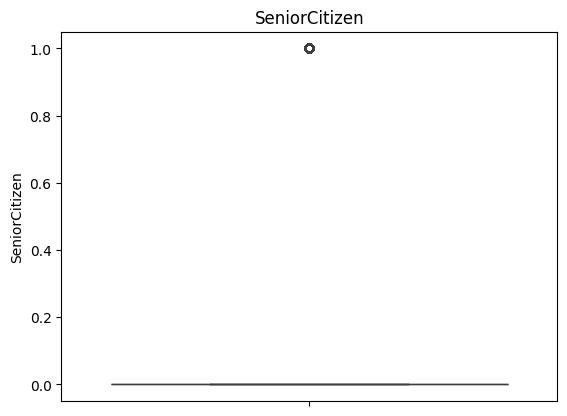

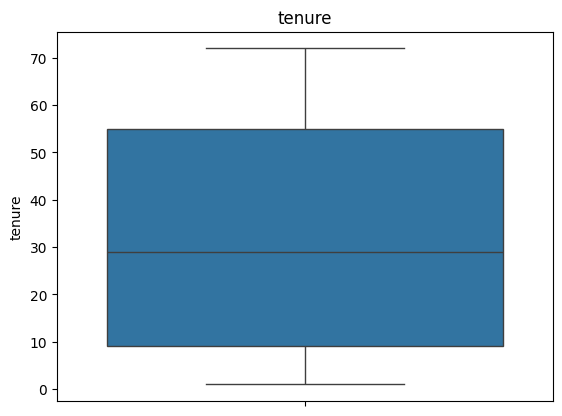

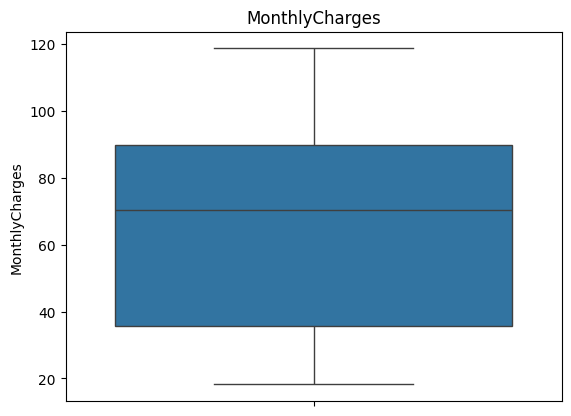

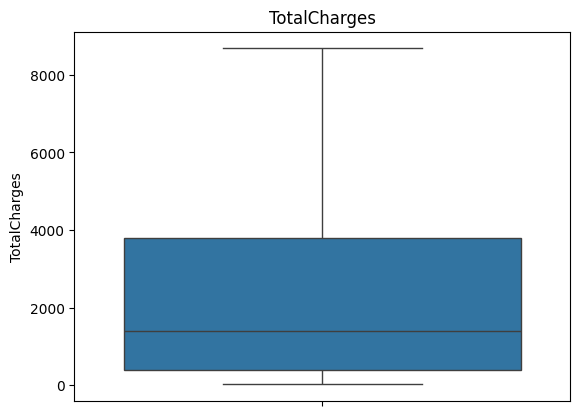

In [56]:
#Check for the outliers
for i in df.columns:
  if (df[i].dtypes!='object'):
    sns.boxplot(df[i])
    plt.title(i)
    plt.show()

-  Random Forest are robust to outliers so dont need to remove the outliers

### STEP 6.Feature Engineering for Encoding,Scaling,Feature creation.


In [57]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

for i in df.columns:
  if df[i].dtypes=='object':
    df[i]=le.fit_transform(df[i])

- Now, all columns with the object data type have been converted into numeric data type columns.


### STEP 7.Divide the dataset into features (x) and target variable (y) for training the model.

In [58]:
# Splitting the dataset.
x=df.iloc[:,:-1]
y=df['Churn']

In [59]:
from sklearn.model_selection import train_test_split

In [60]:
# Dividing the x,y into train and test.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

### STEP 8.Model Selection & Training choose algorithms based on problem type.


In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
model=RandomForestClassifier(class_weight='balanced',n_estimators=50,random_state=23)

In [63]:
model.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50,
                       random_state=23)

In [64]:
y_pred=model.predict(x_test)

### STEP 9: Model Evaluation  
- Assessing the performance of the model based on various parameters.


In [65]:
from sklearn.metrics import *

In [66]:
accuracy_score(y_test,y_pred)

0.7995735607675906

In [67]:
confusion_matrix(y_pred,y_test)

array([[948, 197],
       [ 85, 177]])

In [68]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1033
           1       0.68      0.47      0.56       374

    accuracy                           0.80      1407
   macro avg       0.75      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407



In [69]:
recall_score(y_pred,y_test)

0.6755725190839694

In [70]:
# Training the model with various n_estimators values.
n_estimators=[50,100,150,200,250,300,350,400,450,500,550,600,650]
for i in n_estimators:
    temp_model=RandomForestClassifier(n_estimators=i,random_state=23)
    temp_model.fit(x_train,y_train)
    y_pred=temp_model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    print(f'The accuracy for n_estimator {i} is {acc}')

The accuracy for n_estimator 50 is 0.7867803837953091
The accuracy for n_estimator 100 is 0.7839374555792467
The accuracy for n_estimator 150 is 0.7917555081734187
The accuracy for n_estimator 200 is 0.7938877043354655
The accuracy for n_estimator 250 is 0.7938877043354655
The accuracy for n_estimator 300 is 0.7945984363894811
The accuracy for n_estimator 350 is 0.7931769722814499
The accuracy for n_estimator 400 is 0.7910447761194029
The accuracy for n_estimator 450 is 0.7917555081734187
The accuracy for n_estimator 500 is 0.7917555081734187
The accuracy for n_estimator 550 is 0.7924662402274343
The accuracy for n_estimator 600 is 0.7910447761194029
The accuracy for n_estimator 650 is 0.7903340440653873


- After building the ML model, we evaluated it and achieved " 79 % accuracy ".


### Grind Search CV:-

In [71]:
param_grid={
    'n_estimators':[100,200,300,400],
    'max_depth':[1,5,10,12],
    'min_samples_split':[2,5,7,9],
    'min_samples_leaf':[1,2,4,6],
    'criterion':['gini','entropy']
}

In [72]:
from sklearn.model_selection import GridSearchCV
base_model=RandomForestClassifier(random_state=23)

gv=GridSearchCV(estimator=base_model,param_grid=param_grid,cv=3)

In [74]:
gv.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=23),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [1, 5, 10, 12],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 7, 9],
                         'n_estimators': [100, 200, 300, 400]})

In [75]:
y_pred_2=gv.predict(x_test)

In [76]:
acc_2=accuracy_score(y_test,y_pred_2)
acc_2

0.7953091684434968

In [77]:
confusion_matrix(y_pred_2,y_test)

array([[937, 192],
       [ 96, 182]])

In [78]:
recall_score(y_pred_2,y_test)

0.6546762589928058

### IMBALANCE:-
  - Checking the dataset target column values for balance.
  - If the dataset is not balanced, we are going to perform the "SMOTE" algorithm to balance the dataset.

In [79]:
df['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


- The dataset is imbalanced because the targeted column does not consist of an equal no of values.

In [80]:
from imblearn.over_sampling import SMOTE

In [81]:
sm = SMOTE  (random_state=23)
x_res, y_res = sm.fit_resample(x_train,y_train)

In [82]:
model_3 = RandomForestClassifier(n_estimators=50,random_state=23)
model_3.fit(x_res,y_res)

RandomForestClassifier(n_estimators=50, random_state=23)

In [83]:
y_pred_3=model_3.predict(x_test)

In [84]:
acc_3=accuracy_score(y_test,y_pred_3)
acc_3

0.7654584221748401

In [85]:
confusion_matrix(y_pred_3,y_test)

array([[866, 163],
       [167, 211]])

In [86]:
recall_score(y_pred_3,y_test)

0.5582010582010583

- After building the balanced ML model, we evaluated it and achieved " 76 % accuracy ".
